In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [71]:
df = pd.read_csv('train.csv', usecols=['Age', 'Fare', 'Survived'])

In [72]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [73]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [74]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [75]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [76]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, 1:],
                                                   df['Survived'],
                                                   test_size=0.3,
                                                   random_state=0)

In [77]:
X_train

,Age,Fare
857,51.000000,26.5500
52,49.000000,76.7292
386,1.000000,46.9000
124,54.000000,77.2875
578,29.699118,14.4583
...,...,...
835,39.000000,83.1583
192,19.000000,7.8542
629,29.699118,7.7333
559,36.000000,17.4000


<Axes: xlabel='Age', ylabel='Density'>

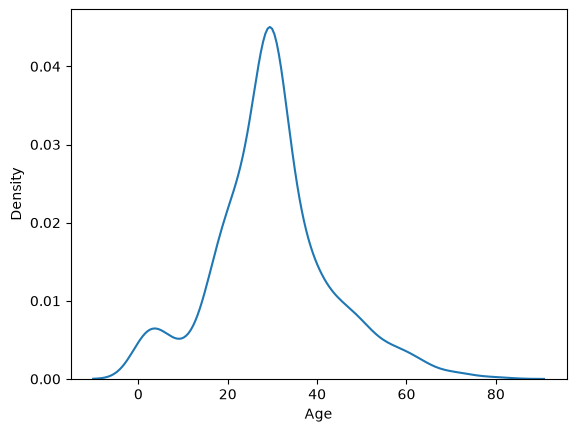

In [78]:
sns.kdeplot(data=X_train, x='Age')

In [79]:
X_train['Age'].skew()

np.float64(0.38392085071686805)

## The data is right skewed.
### Lets apply log transform on it.

In [81]:
X_train['Age'] = np.log1p(X_train['Age'])

In [82]:
X_train['Age'].skew()

np.float64(-2.229970026428339)

<Axes: xlabel='Age', ylabel='Density'>

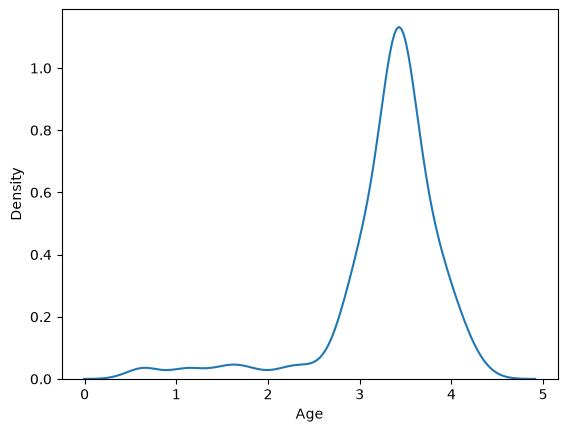

In [83]:
sns.kdeplot(data=X_train, x='Age')

In [84]:
df['Age'].skew()

np.float64(0.4344880940129925)

In [85]:
df['Age'] = np.log1p(df['Age'])

In [87]:
df['Age'].skew()

np.float64(-2.2171039933988435)

### Age column have negative impact of log transformation

In [89]:
df['Fare'].skew()

np.float64(4.787316519674893)

In [90]:
df['Fare'] = np.log1p(df['Fare'])

In [92]:
df['Fare'].skew()

np.float64(0.3949280095189306)

### The fare column has very good impact of log transformation.
### The skewness is significantly decreased